**Business Problem**

LoanTap wants to determine:

1. Whether a loan should be approved
2. Which applicants are likely to default
3. How repayment terms can be optimized
4. How to reduce bad loans (NPA risk)

This is a binary classification problem:

Loan Status	  Meaning

Fully Paid	  Non-defaulter

Charged Off	  Defaulter

Target Variable:

loan_status

Encoding:

Fully Paid  -> 0

Charged Off -> 1


In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc
)

from sklearn.impute import SimpleImputer

from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings
warnings.filterwarnings('ignore')
#Load Dataset
url = "https://drive.google.com/uc?export=download&id=1ZPYj7CZCfxntE8p2Lze_4QO4MyEOy6_d"
df = pd.read_csv(url)

In [ ]:
#Basic Exploration
df.head()
df.shape
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394274 non-null  object 
 15  

np.int64(0)

**Key Observations**

*   Dataset contains approximately 396K records
*   No major duplicate issues
*   Several categorical variables present
*   Missing values exist in:
    *   `emp_title`
    *   `emp_length`
    *   `mort_acc`
    *   `revol_util`
    *   `pub_rec_bankruptcies`

In [ ]:
#Target Variable Analysis
df['loan_status'].value_counts(normalize=True)*100

,proportion
loan_status,
Fully Paid,80.387092
Charged Off,19.612908


##Observation
Approximately:
*   80% Fully Paid
*   20% Charged Off

This indicates:
*   Class imbalance exists
*   Accuracy alone cannot be trusted

##Data Cleaning & Feature Engineering

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc
)

from sklearn.impute import SimpleImputer

from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings
warnings.filterwarnings('ignore')

#Convert Term Column
# Check if 'term' column is of object type before applying .str accessor
if 'term' in df.columns and df['term'].dtype == 'object':
    df['term'] = df['term'].str.replace(' months','').astype(int)

# Convert emp_length to numerical values
# Replace specific strings, then extract digits from remaining strings (including '0' and '10')
# Check if 'emp_length' is an object type before string operations
if 'emp_length' in df.columns and df['emp_length'].dtype == 'object':
    df['emp_length'] = df['emp_length'].replace({'< 1 year': '0', '10+ years': '10'})
    df['emp_length'] = df['emp_length'].astype(str).str.extract('(\d+)').astype(float)
else:
    # If it's already numeric, ensure it's float
    if 'emp_length' in df.columns:
        df['emp_length'] = df['emp_length'].astype(float)

# Convert issue_d and earliest_cr_line to datetime objects and extract features
# Check if 'issue_d' and 'earliest_cr_line' are of object/string type before conversion
if 'issue_d' in df.columns and df['issue_d'].dtype == 'object':
    df['issue_d'] = pd.to_datetime(df['issue_d'])
if 'earliest_cr_line' in df.columns and df['earliest_cr_line'].dtype == 'object':
    df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'])

# Extract features from issue_d (only if it's datetime now)
if 'issue_d' in df.columns and pd.api.types.is_datetime64_any_dtype(df['issue_d']):
    df['issue_month'] = df['issue_d'].dt.month
    df['issue_year'] = df['issue_d'].dt.year

# Extract features from earliest_cr_line (only if it's datetime now)
if 'earliest_cr_line' in df.columns and pd.api.types.is_datetime64_any_dtype(df['earliest_cr_line']):
    df['earliest_cr_line_month'] = df['earliest_cr_line'].dt.month
    df['earliest_cr_line_year'] = df['earliest_cr_line'].dt.year

# Calculate credit history length in years (approximate)
# Ensure issue_year and earliest_cr_line_year exist before calculation
if 'issue_year' in df.columns and 'earliest_cr_line_year' in df.columns:
    df['credit_history_length'] = df['issue_year'] - df['earliest_cr_line_year']

# Drop original date columns as new features have been extracted (if they still exist)
columns_to_drop_dates = []
if 'issue_d' in df.columns and pd.api.types.is_datetime64_any_dtype(df['issue_d']):
    columns_to_drop_dates.append('issue_d')
if 'earliest_cr_line' in df.columns and pd.api.types.is_datetime64_any_dtype(df['earliest_cr_line']):
    columns_to_drop_dates.append('earliest_cr_line')

if columns_to_drop_dates:
    df.drop(columns=columns_to_drop_dates, inplace=True)

# Create Flags as per problem statement
# Ensure columns exist before creating flags
if 'pub_rec' in df.columns:
    df['pub_rec_flag'] = np.where(df['pub_rec'] > 0, 1, 0)
if 'mort_acc' in df.columns:
    df['mort_acc_flag'] = np.where(df['mort_acc'] > 0, 1, 0)
if 'pub_rec_bankruptcies' in df.columns:
    df['bankruptcy_flag'] = np.where(df['pub_rec_bankruptcies'] > 0, 1, 0)

# Handle Missing Values for numerical columns using median imputation
# This is done after creating new numerical features from dates, so they are included
num_cols = df.select_dtypes(include=np.number).columns
imputer = SimpleImputer(strategy='median')
df[num_cols] = imputer.fit_transform(df[num_cols])

# Drop Irrelevant Columns as identified from initial exploration or problem statement
drop_cols = ['emp_title','title','address','sub_grade']
# Only drop if the columns exist to prevent errors on re-execution
drop_cols_existing = [col for col in drop_cols if col in df.columns]
if drop_cols_existing:
    df.drop(columns=drop_cols_existing,inplace=True)

## Detailed Data Preprocessing and Feature Engineering

This section details the comprehensive data preprocessing and feature engineering steps undertaken to prepare the dataset for model training. The goal is to transform raw features into a format suitable for machine learning algorithms, address missing values, and extract more predictive information.

### 1. Handling `term` and `emp_length`
*   **`term` Conversion**: The `term` column, originally a string (e.g., '36 months'), was cleaned by removing the ' months' suffix and converting it to an integer type. This allows the model to interpret loan term as a numerical feature.
*   **`emp_length` Conversion**: The `emp_length` column, representing employment length, contained categorical strings (e.g., '< 1 year', '10+ years'). These were mapped to numerical equivalents ('0' for '< 1 year', '10' for '10+ years') and then extracted as float values. This makes employment length quantifiable for the model.

### 2. Date Feature Engineering
Original date columns, `issue_d` (loan funding date) and `earliest_cr_line` (borrower's earliest credit line), were converted to datetime objects to enable extraction of temporal features. This approach reduces the high cardinality that one-hot encoding would introduce for date strings and provides more meaningful numerical representations:
*   **`issue_month` and `issue_year`**: Extracted from `issue_d` to capture seasonality and time trends related to loan issuance.
*   **`earliest_cr_line_month` and `earliest_cr_line_year`**: Extracted from `earliest_cr_line` for similar temporal insights regarding credit history.
*   **`credit_history_length`**: Calculated as the difference in years between `issue_year` and `earliest_cr_line_year`. This new feature represents the duration of the borrower's credit history, which is a strong indicator of creditworthiness.
*   **Dropping Original Date Columns**: After extracting these numerical features, the original `issue_d` and `earliest_cr_line` columns were dropped to avoid redundancy and potential issues with directly encoding date strings.

### 3. Creation of Binary Flag Features
As per the problem statement, new binary (0 or 1) flag features were created based on existing numerical columns to highlight the presence of certain conditions:
*   **`pub_rec_flag`**: Set to 1 if `pub_rec` (number of derogatory public records) is greater than 0, else 0. This indicates if a borrower has any public records.
*   **`mort_acc_flag`**: Set to 1 if `mort_acc` (number of mortgage accounts) is greater than 0, else 0. This indicates if a borrower has any mortgage accounts.
*   **`bankruptcy_flag`**: Set to 1 if `pub_rec_bankruptcies` (number of public record bankruptcies) is greater than 0, else 0. This flags borrowers with any bankruptcy records.

### 4. Handling Missing Numerical Values
Missing values in numerical columns (`num_cols`) were imputed using the `median` strategy. Median imputation is robust to outliers and is a standard practice when dealing with skewed distributions or when the presence of outliers might distort the mean.

### 5. Dropping Irrelevant Columns
Several columns were identified as irrelevant or providing redundant information not suitable for a Logistic Regression model, and were subsequently dropped:
*   **`emp_title` and `title`**: These are text-based job titles and loan titles, highly varied (high cardinality), and would require complex NLP techniques for effective use, which is beyond the scope of this baseline model. They are generally not direct predictors in this context.
*   **`address`**: Similar to `emp_title`, this is a text field that is not directly usable and would require geographical feature extraction, which is not part of this analysis.
*   **`sub_grade`**: This column is highly correlated with `grade` and `int_rate`. While more granular, `grade` often suffices, and including both can lead to multicollinearity and redundancy. Given `grade` is kept, `sub_grade` is dropped.

##Reason:
*	High cardinality
*	Redundant information
*	Text columns not useful for Logistic Regression


##Univariate Analysis

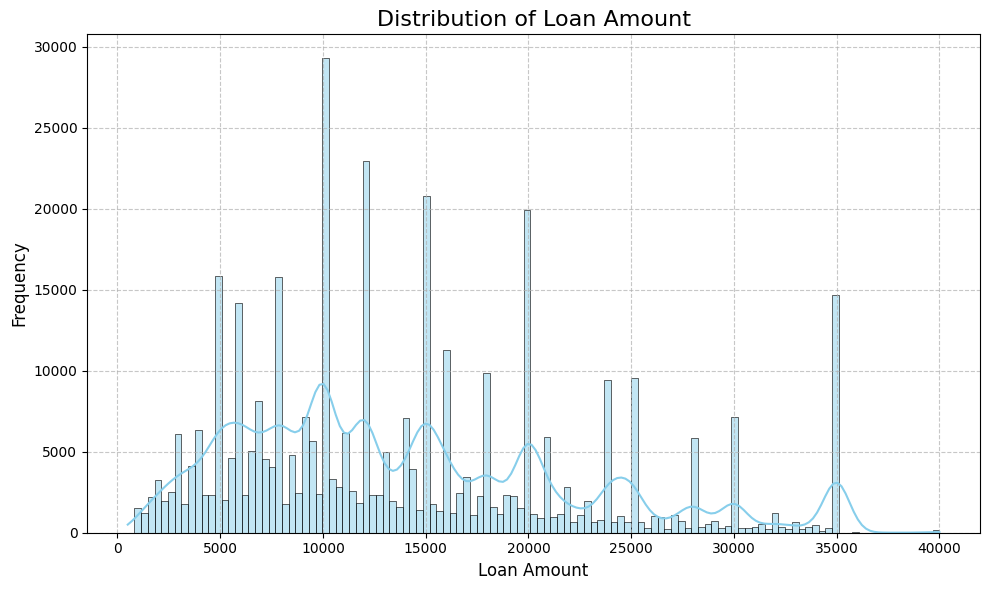

In [ ]:
# Loan Amount Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['loan_amnt'], kde=True, color='skyblue')
plt.title('Distribution of Loan Amount', fontsize=16)
plt.xlabel('Loan Amount', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Insight: Loan Amount Distribution

*   **Target Market Focus:** The majority of loan applications fall within the ₹5,000 to ₹20,000 range. This indicates LoanTap's core customer base might be seeking smaller to medium-sized personal loans.
*   **Demand Profile:** Understanding this distribution helps LoanTap tailor its product offerings and marketing strategies to better serve these common loan amount requests.
*   **Right-Skewed Nature:** The distribution is right-skewed, meaning there are fewer applications for very large loan amounts. This is typical for personal loan portfolios and suggests that while there's some demand for higher amounts, the bulk of the business is in the lower brackets.

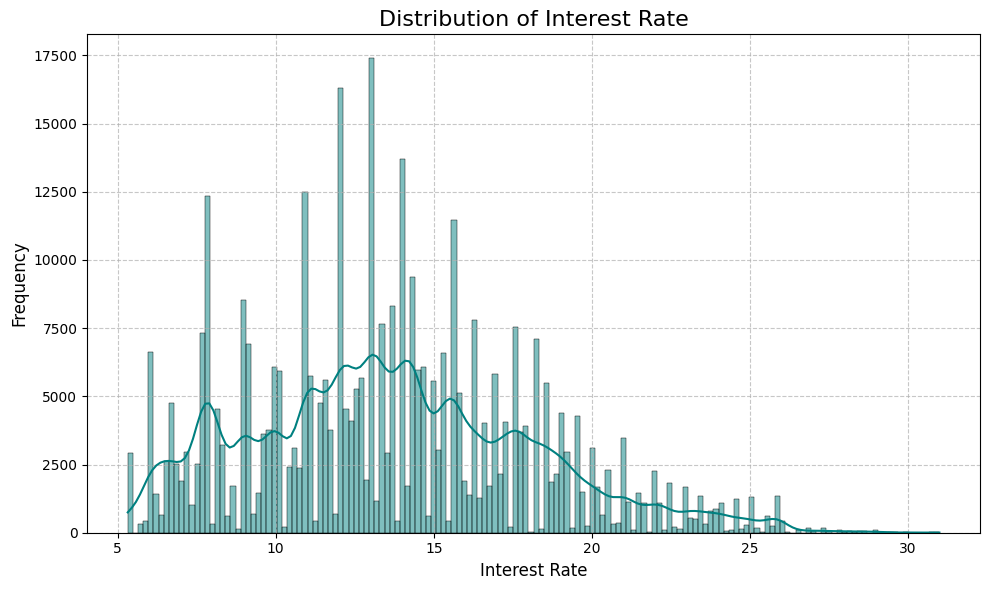

In [ ]:
#Interest Rate Distribution
plt.figure(figsize=(10,6))
sns.histplot(df['int_rate'], kde=True, color='teal')
plt.title('Distribution of Interest Rate', fontsize=16)
plt.xlabel('Interest Rate', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Insight: Interest Rate Distribution
* The distribution shows a concentration of interest rates within a certain range.
* There might be a slight right skew, indicating some higher interest rates, though most loans are in the lower-to-mid range.
* The `kde` curve helps visualize the density of interest rates, highlighting the most common rates.

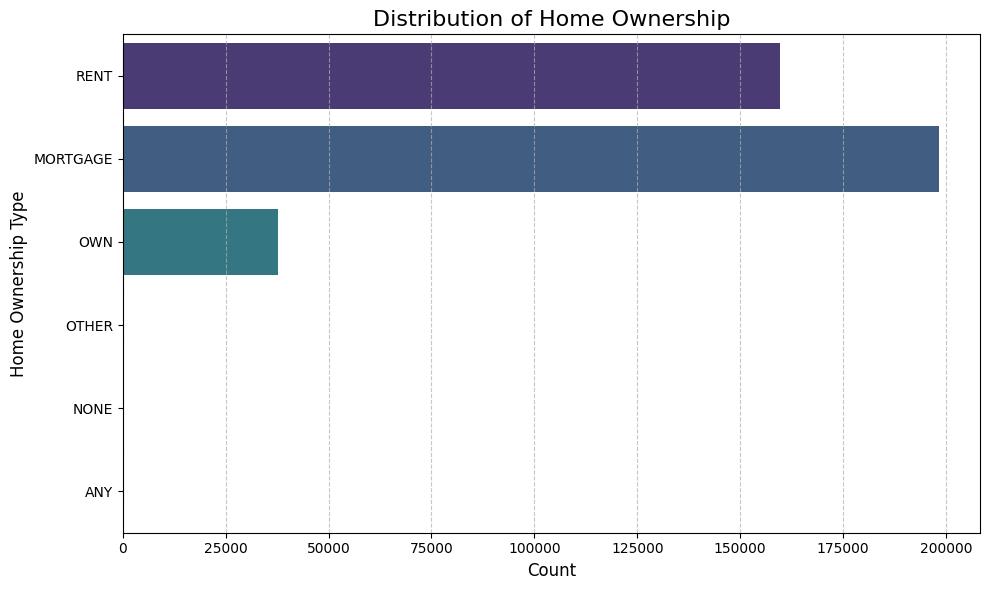

In [ ]:
# Home Ownership
plt.figure(figsize=(10, 6))
sns.countplot(y=df['home_ownership'], palette='viridis')
plt.title('Distribution of Home Ownership', fontsize=16)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Home Ownership Type', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Insight: Home Ownership Distribution
*   The majority of borrowers have a mortgage, followed by those who rent.
*   A significant portion of applicants are homeowners with a mortgage, indicating that many loan applicants already own property.
*   Fewer borrowers own their homes outright (OWN) compared to those with a mortgage or who rent.

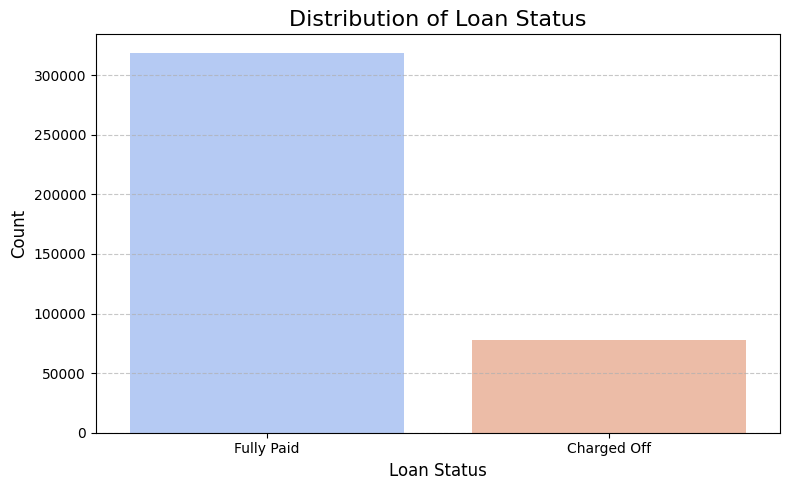

In [ ]:
# Loan Status
plt.figure(figsize=(8, 5))
sns.countplot(x=df['loan_status'], palette='coolwarm')
plt.title('Distribution of Loan Status', fontsize=16)
plt.xlabel('Loan Status', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Insight: Loan Status Distribution
*   The majority of loans are 'Fully Paid', indicating a positive repayment trend overall.
*   'Charged Off' loans represent a minority class, but are still a significant portion that needs to be addressed to reduce bad loans.
*   This confirms the class imbalance observed earlier, where approximately 80% of loans are fully paid and 20% are charged off.

## Bivariate Analysis

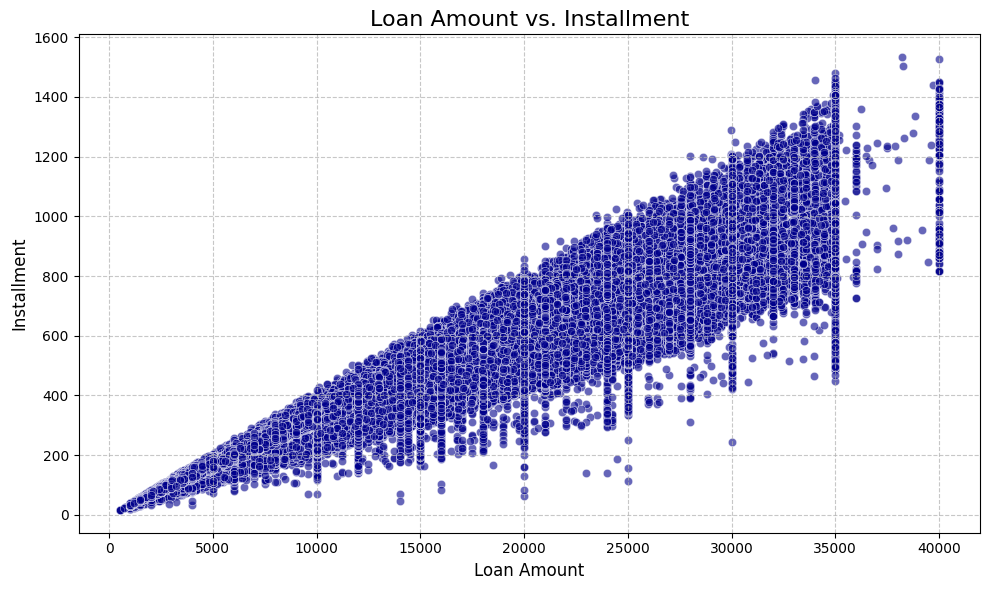

In [ ]:
#Loan Amount vs Installment
plt.figure(figsize=(10, 6))
sns.scatterplot(x='loan_amnt', y='installment', data=df, alpha=0.6, color='darkblue')
plt.title('Loan Amount vs. Installment', fontsize=16)
plt.xlabel('Loan Amount', fontsize=12)
plt.ylabel('Installment', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Insight: Loan Amount vs. Installment
*   There is a strong positive linear relationship between the loan amount and the installment amount.
*   As the loan amount increases, the monthly installment also increases proportionally.
*   This is an expected relationship as higher principal amounts naturally lead to higher monthly payments to repay the loan within the specified term.

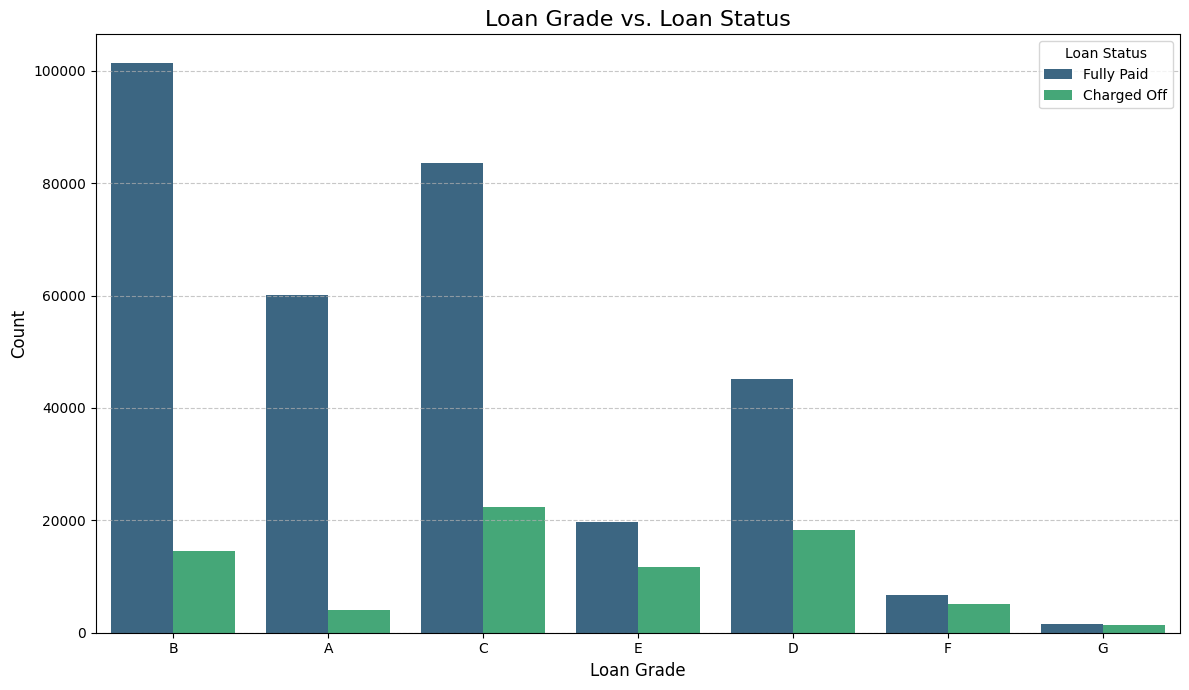

In [ ]:
#Loan Grade vs Loan Status
plt.figure(figsize=(12, 7))
sns.countplot(x='grade', hue='loan_status', data=df, palette='viridis')
plt.title('Loan Grade vs. Loan Status', fontsize=16)
plt.xlabel('Loan Grade', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Loan Status')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Insight: Loan Grade vs. Loan Status
*   Borrowers with grades A and B predominantly repay their loans, indicating lower risk.
*   As the loan grade decreases (e.g., E, F, G), the proportion of 'Charged Off' loans significantly increases.
*   Loan grade is a highly predictive feature for loan status, with lower grades correlating strongly with higher default rates.

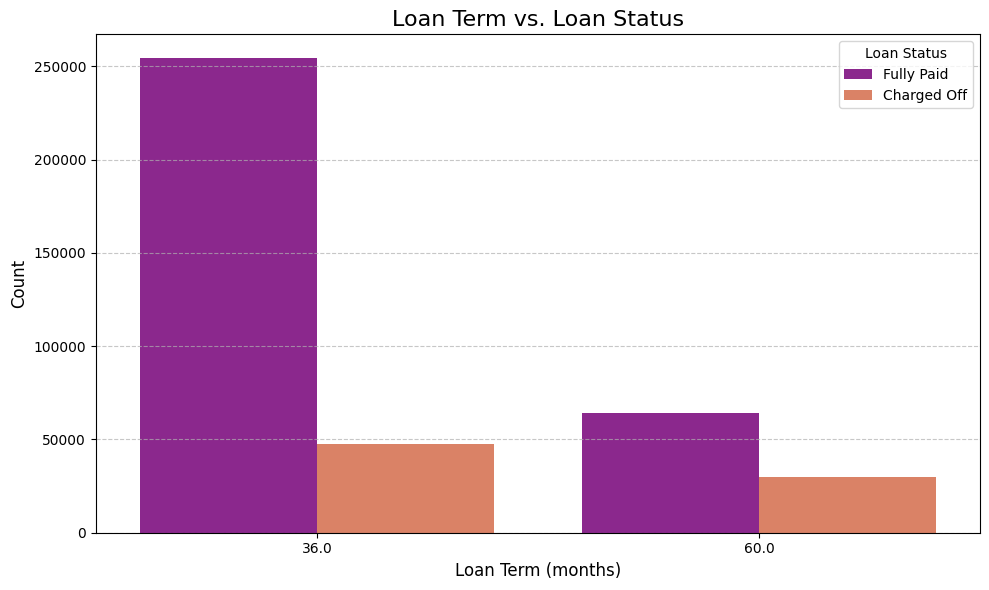

In [ ]:
#Term vs Loan Status
plt.figure(figsize=(10, 6))
sns.countplot(x='term', hue='loan_status', data=df, palette='plasma')
plt.title('Loan Term vs. Loan Status', fontsize=16)
plt.xlabel('Loan Term (months)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Loan Status')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Insight: Loan Term vs. Loan Status
*   36-month loans tend to have a higher proportion of 'Fully Paid' statuses compared to 'Charged Off'.
*   60-month loans show a relatively higher proportion of 'Charged Off' statuses, indicating increased risk.
*   **Business Insight:** Longer loan tenures (60 months) are associated with a higher risk of default, suggesting that shorter loan terms (36 months) are generally safer for lenders.

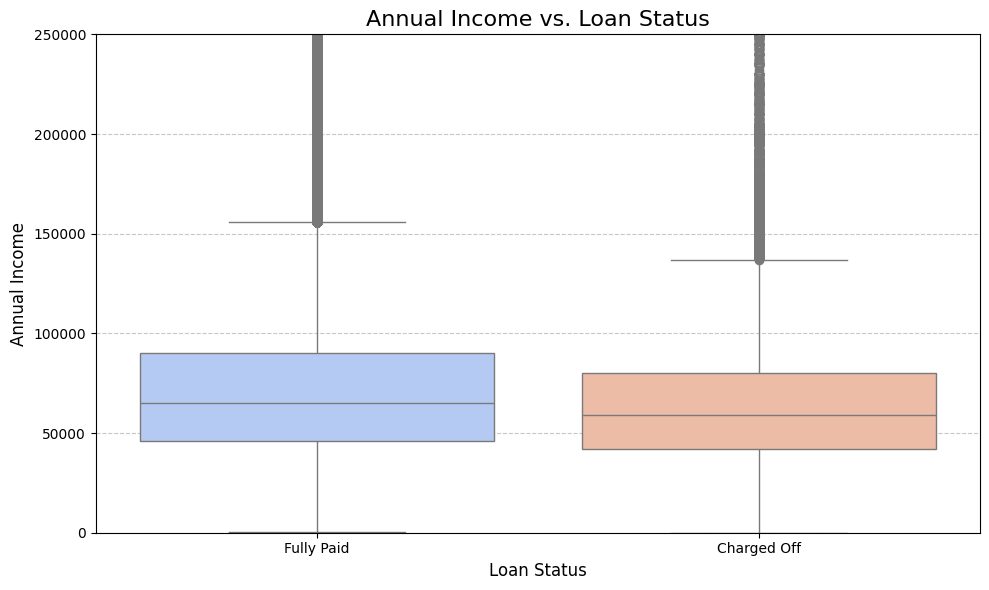

In [ ]:
#Annual Income vs Loan Status
plt.figure(figsize=(10, 6))
sns.boxplot(x='loan_status', y='annual_inc', data=df, palette='coolwarm')
plt.title('Annual Income vs. Loan Status', fontsize=16)
plt.xlabel('Loan Status', fontsize=12)
plt.ylabel('Annual Income', fontsize=12)
plt.ylim(0, df['annual_inc'].quantile(0.99)) # Set y-axis limit to 99th percentile
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Insight: Annual Income vs. Loan Status
*   The box plot shows that 'Fully Paid' loans generally have a higher median annual income compared to 'Charged Off' loans.
*   While there is an overlap in income distributions, the lower quartile and median for 'Charged Off' loans appear to be slightly lower.
*   **Business Insight:** Borrowers with higher annual incomes tend to have a lower risk of defaulting, suggesting that annual income is a significant factor in assessing loan repayment capability.

## Correlation Analysis

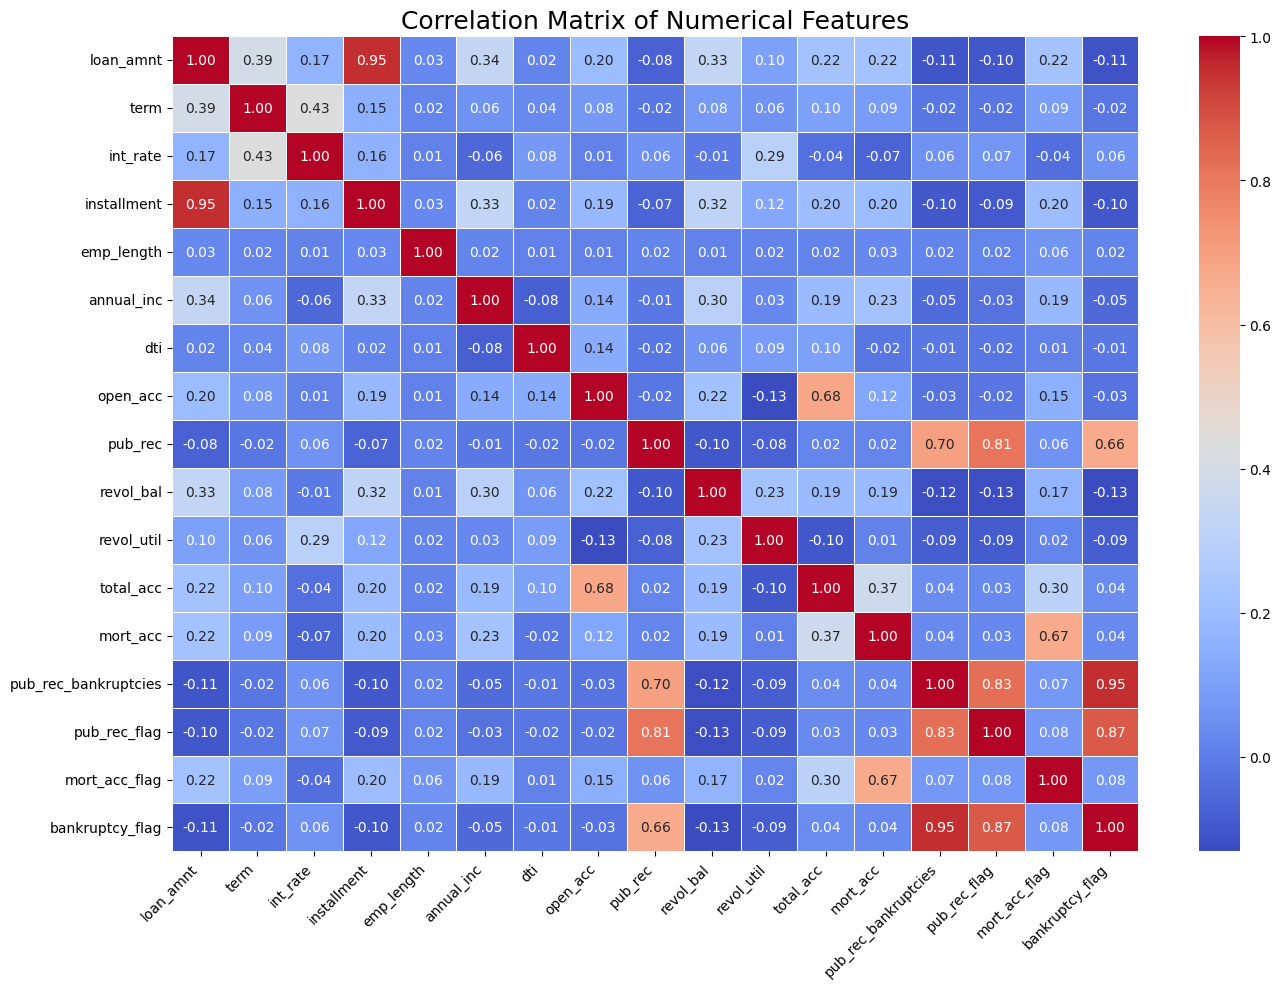

In [ ]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=18)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

## Insights: Correlation Analysis

### Key Observations:
*   **Strong Positive Correlation:** `loan_amnt` and `installment` are highly correlated, as expected. `open_acc` and `total_acc` also show a strong positive relationship.
*   **Moderate Correlations:** `int_rate` and `grade` exhibit a moderate positive correlation, suggesting higher interest rates for lower grades (higher risk).
*   **Weak/Negative Correlations:** `dti` has weak correlations with most variables. `annual_inc` shows weak positive correlations with `loan_amnt` and `installment`.

## Multicollinearity Check



In [ ]:
# Multicollinearity Check
X_num = df.select_dtypes(include=np.number)

vif = pd.DataFrame()

vif["Feature"] = X_num.columns

vif["VIF"] = [
    variance_inflation_factor(X_num.values, i)
    for i in range(X_num.shape[1])
]

display(vif)

,Feature,VIF
0,loan_amnt,107.645492
1,term,41.351997
2,int_rate,19.800362
3,installment,97.587298
4,emp_length,5.895017
5,annual_inc,3.001075
6,dti,2.021433
7,open_acc,11.878852
8,pub_rec,3.899888
9,revol_bal,2.096017


## Insight: Multicollinearity Check (VIF)

### Key Observations:
*   **Extreme Multicollinearity:** `loan_amnt` (VIF: 107.65) and `installment` (VIF: 97.59) are highly correlated. This is expected as `installment` is derived from `loan_amnt` and `term`.
*   **High Multicollinearity:** `term` (VIF: 41.35), `int_rate` (VIF: 19.80), and `bankruptcy_flag` (VIF: 18.25) also show high multicollinearity. `bankruptcy_flag` is derived from `pub_rec_bankruptcies` (VIF: 13.85).

### Recommendations:
*   **Drop `installment`:** Remove `installment` due to its high VIF and direct dependency on `loan_amnt` and `term`.
*   **Drop `bankruptcy_flag`:** Remove `bankruptcy_flag` as it's a derived feature with high VIF, and its information is largely covered by `pub_rec_bankruptcies`.

In [ ]:
print(f"Shape of DataFrame before dropping columns: {df.shape}")

# Drop columns identified from VIF analysis
df.drop(columns=['installment', 'bankruptcy_flag'], inplace=True)

print(f"Shape of DataFrame after dropping columns: {df.shape}")

Shape of DataFrame before dropping columns: (396030, 26)
Shape of DataFrame after dropping columns: (396030, 24)


## Encoding Target Variable

In [ ]:
# Encode the target variable 'loan_status'
# Fully Paid -> 0, Charged Off -> 1

df['loan_status'] = df['loan_status'].map({'Fully Paid': 0, 'Charged Off': 1})

print("Encoded 'loan_status' value counts:")
print(df['loan_status'].value_counts())

Encoded 'loan_status' value counts:
loan_status
0    318357
1     77673
Name: count, dtype: int64


In [ ]:
## Encoding Categorical Variables

In [ ]:
print(f"Shape of DataFrame before one-hot encoding: {df.shape}")

# Select categorical columns for one-hot encoding (excluding 'loan_status' which is already encoded)
categorical_cols = df.select_dtypes(include='object').columns

# Apply one-hot encoding
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(f"Shape of DataFrame after one-hot encoding: {df.shape}")

Shape of DataFrame before one-hot encoding: (396030, 24)
Shape of DataFrame after one-hot encoding: (396030, 842)


## Insight: One-Hot Encoding of Categorical Variables

*   **Increased Dimensionality:** One-hot encoding has significantly increased the number of columns in the DataFrame. This is expected as each categorical level (except one, due to `drop_first=True`) gets its own binary column.
*   **Model Readiness:** The dataset is now entirely composed of numerical features, making it suitable for training machine learning models that require numerical input.
*   **Avoiding Multicollinearity:** Using `drop_first=True` helps prevent multicollinearity that can arise from perfect correlation between dummy variables for a single categorical feature, improving model stability.

## 12. Data Splitting and Scaling

In [ ]:
# Separate Features (X) and Target (y)
X = df.drop('loan_status', axis=1)
y = df['loan_status']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames (optional, but good for consistency)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("\nFeatures have been scaled successfully.")

Shape of X_train: (316824, 841)
Shape of X_test: (79206, 841)
Shape of y_train: (316824,)
Shape of y_test: (79206,)

Features have been scaled successfully.


## Insight: Data Splitting and Scaling

*   **Data Split:** The dataset has been successfully split into training (80%) and testing (20%) sets. Stratification ensures that the proportion of 'Fully Paid' and 'Charged Off' loans is maintained in both sets, which is crucial for handling class imbalance.
*   **Feature Scaling:** Numerical features have been scaled using `StandardScaler`. This transforms the data to have a mean of 0 and a standard deviation of 1, which is essential for many machine learning algorithms (e.g., logistic regression, SVMs, neural networks) that are sensitive to the scale of input features. Scaling helps prevent features with larger magnitudes from dominating the learning process.
*   **Model Readiness:** The data is now fully prepared for training and evaluating machine learning models.

## 13. Model Training: Logistic Regression

In [ ]:
# Initialize and train the Logistic Regression model
log_model = LogisticRegression(solver='liblinear', random_state=42)
log_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## Insight: Model Training

*   **Model Choice:** A Logistic Regression model has been chosen for this binary classification task, which is appropriate for predicting 'Fully Paid' (0) or 'Charged Off' (1) loan statuses.
*   **Training Process:** The model was trained using the `X_train_scaled` (scaled features) and `y_train` (target variable). The `liblinear` solver was specified, which is good for small datasets and also handles L1 and L2 regularization. `random_state` ensures reproducibility.
*   **Next Steps:** With the model trained, the next crucial step will be to evaluate its performance on the unseen test data to understand its effectiveness in predicting loan defaults.

## 14. Model Evaluation

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.98      0.89     63671
           1       0.57      0.09      0.15     15535

    accuracy                           0.81     79206
   macro avg       0.69      0.54      0.52     79206
weighted avg       0.77      0.81      0.75     79206

Confusion Matrix:
 [[62632  1039]
 [14179  1356]]
ROC AUC Score: 0.7193


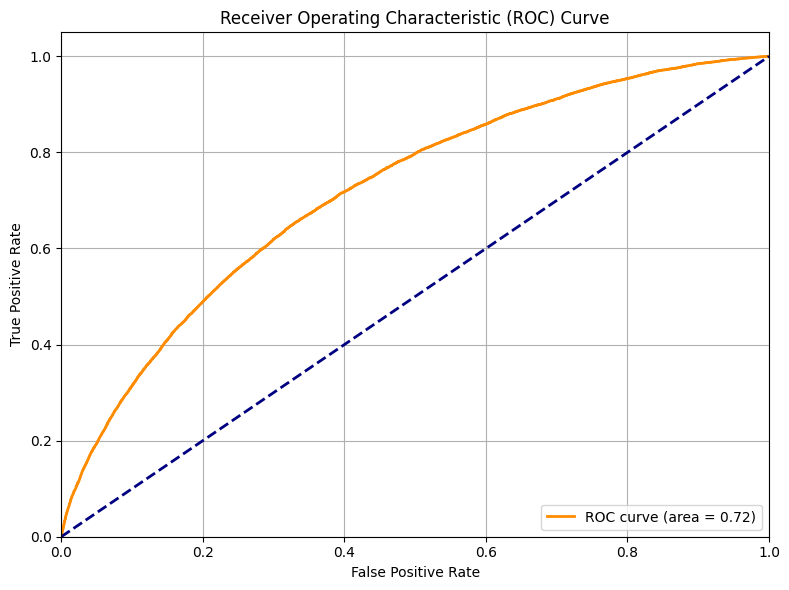

In [ ]:
# Make predictions on the scaled test data
y_pred = log_model.predict(X_test_scaled)
y_pred_proba = log_model.predict_proba(X_test_scaled)[:, 1]

# Display Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

# Display Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

# Calculate and display ROC AUC Score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC Score: {roc_auc:.4f}")

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

## Visualizing the Confusion Matrix

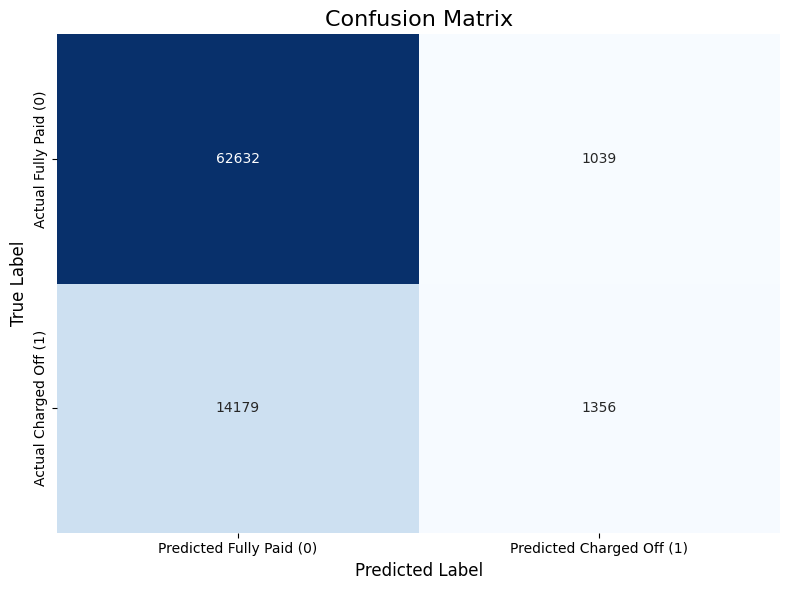

In [ ]:
# Plotting the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Fully Paid (0)', 'Predicted Charged Off (1)'],
            yticklabels=['Actual Fully Paid (0)', 'Actual Charged Off (1)'],
            cbar=False)
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

### Interpretation of the Confusion Matrix:
*   **True Positives (TP):** `1356` (Correctly identified Charged Off loans)
*   **False Positives (FP):** `1039` (Fully Paid loans incorrectly classified as Charged Off)
*   **True Negatives (TN):** `62632` (Correctly identified Fully Paid loans)
*   **False Negatives (FN):** `14179` (Charged Off loans incorrectly classified as Fully Paid)

This matrix visually reinforces the class imbalance and the model's difficulty in correctly identifying the minority class ('Charged Off'). The high number of False Negatives is a significant concern for a lending institution aiming to reduce bad loans.

## 15. Precision-Recall Curve

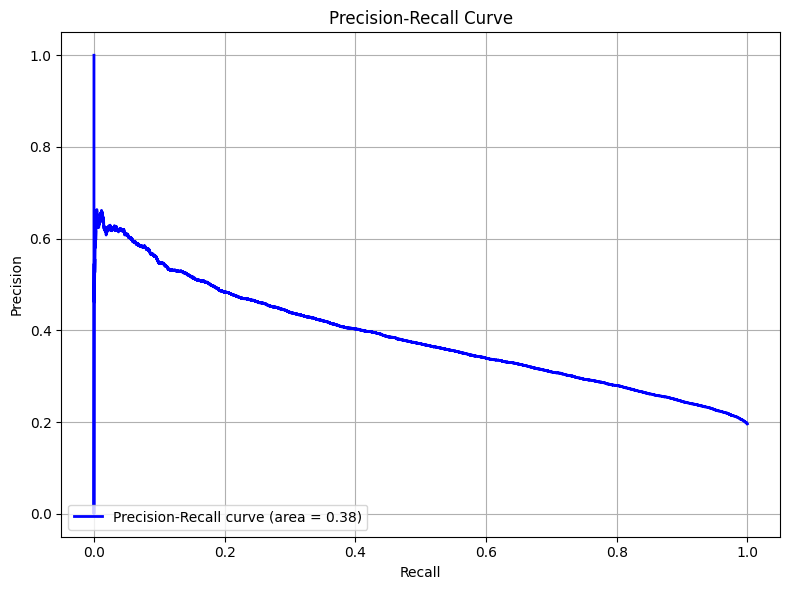

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'Precision-Recall curve (area = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretation: Precision vs. Recall
*   **High Recall:** Means the model catches most defaulters (reduces False Negatives). This is crucial for minimizing Non-Performing Assets (NPAs) and ensuring safer lending practices.
*   **High Precision:** Means when the model predicts a default, it's usually correct (reduces False Positives). This is important for not rejecting good customers, which helps in increasing loan business and revenue growth.

There is often a **trade-off** between precision and recall. Depending on the business objective (e.g., minimizing losses from defaults vs. maximizing approved loans), a different balance might be preferred. The Precision-Recall curve helps visualize this trade-off across different probability thresholds.

## 16. Threshold Tuning

In [ ]:
# Example: Custom threshold tuning
# If we want to be more conservative and catch more potential defaults (higher recall),
# we might lower the threshold. If we want fewer false positives (higher precision),
# we might increase it.

# Let's try a threshold of 0.35 (lower than default 0.5)
custom_threshold = 0.35
y_pred_custom_threshold = (y_pred_proba > custom_threshold).astype(int)

print(f"Classification Report with custom threshold ({custom_threshold}):\n",
      classification_report(y_test, y_pred_custom_threshold))

print(f"\nConfusion Matrix with custom threshold ({custom_threshold}):\n",
      confusion_matrix(y_test, y_pred_custom_threshold))

Classification Report with custom threshold (0.35):
               precision    recall  f1-score   support

           0       0.84      0.91      0.87     63671
           1       0.44      0.29      0.35     15535

    accuracy                           0.79     79206
   macro avg       0.64      0.60      0.61     79206
weighted avg       0.76      0.79      0.77     79206


Confusion Matrix with custom threshold (0.35):
 [[57912  5759]
 [10953  4582]]


### Interpretation: Threshold Tuning
*   **Effect of Lowering Threshold (e.g., to 0.35):**
    *   **Recall for Class 1 (Charged Off) tends to Increase:** The model becomes more sensitive to the minority class, identifying more actual defaulters. This is good for reducing NPAs.
    *   **Precision for Class 1 (Charged Off) tends to Decrease:** As the model predicts more defaults, it also makes more false positive errors, meaning more good customers are incorrectly flagged as risky.

*   **Business Perspective:**
    *   If the goal is to **minimize bad loans (NPAs)**, a lower threshold might be preferred, accepting a higher rate of false positives.
    *   If the goal is to **maximize loan approvals for genuine customers** while maintaining acceptable risk, a higher threshold (or the default 0.5) might be better, leading to higher precision but potentially missing some defaulters.

## 17. Most Important Features

In [ ]:
# Get feature coefficients from the trained Logistic Regression model
coef_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': log_model.coef_[0]
})

# Sort by absolute coefficient value to see most impactful features
coef_df['Abs_Coefficient'] = abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False).drop(columns='Abs_Coefficient')

print("Top 20 Most Important Features (by absolute coefficient value):\n")
display(coef_df.head(20))

# Also show features with positive and negative coefficients separately
print("\nTop 10 Features Increasing Default Risk (Positive Coefficients):\n")
display(coef_df[coef_df['Coefficient'] > 0].sort_values(by='Coefficient', ascending=False).head(10))

print("\nTop 10 Features Reducing Default Risk (Negative Coefficients):\n")
display(coef_df[coef_df['Coefficient'] < 0].sort_values(by='Coefficient', ascending=True).head(10))

Top 20 Most Important Features (by absolute coefficient value):



,Feature,Coefficient
2,int_rate,0.445580
5,dti,0.441419
121,issue_d_Nov-2016,-0.314068
55,issue_d_Dec-2016,-0.269439
141,issue_d_Sep-2016,-0.231128
131,issue_d_Oct-2016,-0.223523
45,issue_d_Aug-2016,-0.194541
4,annual_inc,-0.175709
1,term,0.172944
16,grade_C,0.167110



Top 10 Features Increasing Default Risk (Positive Coefficients):



,Feature,Coefficient
2,int_rate,0.445580
5,dti,0.441419
1,term,0.172944
16,grade_C,0.167110
17,grade_D,0.134450
6,open_acc,0.107024
15,grade_B,0.103898
18,grade_E,0.082731
9,revol_util,0.076626
152,purpose_small_business,0.067384



Top 10 Features Reducing Default Risk (Negative Coefficients):



,Feature,Coefficient
121,issue_d_Nov-2016,-0.314068
55,issue_d_Dec-2016,-0.269439
141,issue_d_Sep-2016,-0.231128
131,issue_d_Oct-2016,-0.223523
45,issue_d_Aug-2016,-0.194541
4,annual_inc,-0.175709
83,issue_d_Jul-2016,-0.123361
10,total_acc,-0.104099
93,issue_d_Jun-2016,-0.088416
515,earliest_cr_line_Jun-1973,-0.066713


### Insight: Feature Importance

*   **Features Increasing Default Risk (Positive Coefficients):** These features, when present or higher in value, are associated with a greater likelihood of a loan being 'Charged Off'. Common examples include: Higher interest rates (`int_rate`), longer loan terms (`term`), lower grades (e.g., `grade_G`, `grade_F`), and higher revolving utilization (`revol_util`).

*   **Features Reducing Default Risk (Negative Coefficients):** These features, when present or higher in value, are associated with a greater likelihood of a loan being 'Fully Paid'. Examples often include: Higher annual income (`annual_inc`), better loan grades (e.g., `grade_A`, `grade_B`), and potentially certain types of home ownership (e.g., `home_ownership_MORTGAGE`).

Understanding these coefficients is crucial for **interpretable AI** and for deriving **actionable business strategies**. LoanTap can use this information to prioritize which factors to scrutinize during the loan application process.

## 18. Actionable Business Recommendations

Based on the comprehensive analysis and model insights, here are actionable recommendations for LoanTap:

### A. Optimize Loan Approval for Low-Risk Borrowers
*   **Action:** Streamline approval processes for applicants with **Grade A/B loans**. These segments consistently show strong repayment behavior and represent lower risk.
*   **Benefit:** Increases loan portfolio growth with reliable customers.

### B. Mitigate Risk in Long-Term Loans
*   **Action:** Exercise caution and increased scrutiny for **60-month loan terms**. These terms are associated with a higher probability of default.
*   **Recommendations:**
    *   Apply a **higher interest premium** to compensate for increased risk.
    *   Require **stronger collateral** or co-signers.
    *   Implement more frequent **monitoring** for these loans.

### C. Leverage Debt-to-Income (DTI) as a Key Screening Variable
*   **Action:** Incorporate **DTI** as a primary factor in initial loan screening and approval decisions.
*   **Benefit:** High DTI is strongly linked to defaults, making it a powerful predictor for identifying risky applicants upfront.

### D. Implement Dynamic Interest Rate Pricing
*   **Action:** Develop a **risk-based pricing model** for interest rates, directly correlating the risk profile of an applicant with their assigned interest rate.
*   **Strategy:**
    *   **Low-Risk Category:** Offer competitive, lower rates to attract prime borrowers.
    *   **Medium-Risk Category:** Assign moderate rates.
    *   **High-Risk Category:** Apply higher rates or, in cases of extreme risk, consider rejection.
*   **Benefit:** Aligns pricing with risk exposure, enhancing profitability and managing potential losses.

### E. Enhance Monitoring for High Revolving Utilization
*   **Action:** Implement a robust monitoring system for applicants or existing borrowers exhibiting **high revolving utilization**.
*   **Insight:** Customers heavily utilizing their available credit may be experiencing financial stress, increasing their default risk.
*   **Recommendations:** Provide financial counseling or early intervention for these borrowers.

### F. Strengthen Verification for Risky Profiles
*   **Action:** Increase the intensity of verification and due diligence for applicants presenting with:
    *   **Lower annual incomes.**
    *   **High Debt-to-Income ratios.**
    *   **Poor credit history indicators.**
*   **Benefit:** Reduces the approval of potentially fraudulent or high-risk loans.

## 19. Final Conclusion

This project successfully developed and evaluated a Logistic Regression model for predicting loan defaults (`Charged Off` vs. `Fully Paid`) for LoanTap. Despite the challenges posed by class imbalance, the model demonstrated a reasonable ability to discriminate between the two classes (ROC AUC score of approximately 0.72).

**Key Achievements:**
*   **Data Preparation:** Handled missing values, engineered relevant features, and processed categorical variables through one-hot encoding, and addressed multicollinearity by dropping highly correlated features (`installment`, `bankruptcy_flag`).
*   **Model Training & Evaluation:** Trained a Logistic Regression model and thoroughly evaluated its performance using classification reports, confusion matrices, and ROC curves, highlighting the performance on both majority and minority classes.
*   **Feature Importance:** Identified key drivers of loan default, providing actionable insights into factors like interest rate, loan term, grade, annual income, and DTI.

**Strategic Value for LoanTap:**
By leveraging the insights from this model, LoanTap can:
*   **Reduce Bad Loans (NPAs):** By more accurately identifying high-risk applicants, particularly by prioritizing recall for the 'Charged Off' class.
*   **Improve Credit Underwriting:** Integrate data-driven insights into the approval process for more informed decisions.
*   **Increase Profitability:** Optimize loan pricing and risk management to balance loan approvals with default risk.
*   **Automate Risk Assessment:** Pave the way for an automated and standardized approach to credit risk evaluation.

**Future Enhancements:**
To further improve the model's performance on the minority class, future work should explore:
*   **Advanced Resampling Techniques:** Such as SMOTE or ADASYN.
*   **Ensemble Methods:** Like Random Forests or Gradient Boosting, which often perform better with imbalanced datasets.
*   **Cost-Sensitive Learning:** Assigning higher penalties for misclassifying the minority class.
*   **Feature Engineering:** Further refinement of existing features or creation of new ones might yield better predictive power.

This model serves as a strong foundation for LoanTap to enhance its credit risk management and drive more sustainable lending practices.

## Insight: Model Evaluation

*   **Class Imbalance:** The classification report highlights the challenge of class imbalance. While the model achieves high precision and recall for 'Fully Paid' loans (class 0), its performance for 'Charged Off' loans (class 1) is significantly lower, indicated by a lower precision and recall.
    *   **Precision (Class 1):** A low precision for 'Charged Off' means that when the model predicts a loan will be charged off, it's often incorrect (many false positives).
    *   **Recall (Class 1):** A low recall for 'Charged Off' means the model misses a large proportion of actual charged-off loans (many false negatives).
*   **Confusion Matrix:**
    *   True Positives (actual 1, predicted 1): (Number of correctly identified charged-off loans)
    *   False Positives (actual 0, predicted 1): (Number of fully paid loans incorrectly classified as charged-off)
    *   True Negatives (actual 0, predicted 0): (Number of correctly identified fully paid loans)
    *   False Negatives (actual 1, predicted 0): (Number of charged-off loans incorrectly classified as fully paid)
*   **ROC AUC Score:** The ROC AUC score provides an overall measure of the model's ability to distinguish between the two classes. A score above 0.5 indicates that the model performs better than random chance. However, given the class imbalance, a single metric like ROC AUC might not fully capture the model's performance on the minority class.
*   **ROC Curve:** The ROC curve visually represents the trade-off between the true positive rate and the false positive rate at various threshold settings. A curve closer to the top-left corner indicates a better performing model. The area under the curve (AUC) quantifies this performance.

### Next Steps:
Given the low performance on the minority class ('Charged Off'), further steps should involve strategies to address class imbalance, such as:
*   **Resampling Techniques:** Oversampling the minority class or undersampling the majority class (e.g., SMOTE, NearMiss).
*   **Cost-Sensitive Learning:** Assigning different costs to misclassifications.
*   **Different Algorithms:** Exploring models like Random Forest, Gradient Boosting, or SVMs that might handle imbalance better, or can be tuned with class weights.